In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import ExoWeave Coupler
from exoweave import ExoCoupler

from fuzzycore.utils import generate_gaussian_z_profile
from fuzzycore import constants as c


# Set A&A publication-ready plotting parameters
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.linewidth': 1.2
})

import os

# Put a leash on Intel MKL and all other C-level math libraries!
# This strictly prevents them from spawning deadlocking threads.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [2]:
# =============================================================================
# 1. SETUP SUB-NEPTUNE PARAMETERS
# =============================================================================
M_JUP_IN_EARTH = 317.83
target_mass_mjup = 8.0 * (c.M_EARTH / c.M_JUPITER)

base_params = {
    "mass": target_mass_mjup,
    "T_irr": 200.0,              # Surface equilibrium temperature (K)
    "T_int": 100.0,              # Deep internal heat flux (K)
    "Met": 1.0,                  # Bulk atmospheric metallicity (approx 5x solar)
    "core_mass_earth": 7.45,      # 7.0 M_earth core leaves 1.0 M_earth for the envelope!
    'M_water': 0.5 * c.M_EARTH, 
    "iron_fraction": 0.33,       # Earth-like rock/iron ratio
    "f_sed": 3.0,
    "kzz": 8.0,
    "g_1bar": 15.0,
    "debug": True
}

config = {
    "max_iterations": 20,              
    "mass_convergence_threshold": 0.01,
    "p_bottom_bar": 1000.0,
    "output_dir": "./outputs/subneptune_test",
    "resolution": 50,           
    "target_resolution": 50,
    "min_p_link_bar": 1    
}

# Define the two distinct architectures
params_sharp = base_params.copy()
params_sharp["sigma_val"] = 0.0  

params_fuzzy = base_params.copy()
params_fuzzy["sigma_val"] = 0.30  # Fuzzy Core (Dilute gradient, layered convection)

In [3]:
# =============================================================================
# 2. RUN THE COUPLED MODELS
# =============================================================================
print(f'🚀 Launching Sharp Core Model (sigma = {params_sharp["sigma_val"]})...')
coupler_sharp = ExoCoupler(target_params=params_sharp, config=config)
results_sharp = coupler_sharp.run()

print("\n🚀 Launching Fuzzy Core Model (sigma = 0.30)...")
coupler_fuzzy = ExoCoupler(target_params=params_fuzzy, config=config)
results_fuzzy = coupler_fuzzy.run()


INFO: 👢 Bootstrapping initial gravity via 1-bar interior pre-solve...


🚀 Launching Sharp Core Model (sigma = 0.0)...

🛑 [FUZZYCORE TRIPWIRE: EXACT INPUTS RECEIVED] 🛑
Trial ID: bootstrap | Mode: mass
Target Value: 4.77760e+25 [kg]
   -> Equivalent to: 8.00 Earth Masses
   -> Equivalent to: 0.02517 Jupiter Masses
------------------------------------------------------------
Raw Parameters Dictionary:
  - P_surf: 1.0
  - T_surf: 140.0
  - M_core: 4.449e+25 ⚠️ (MASSIVE NUMBER)
  - iron_fraction: 0.33
  - z_base: 0.15
  - Y_ratio: 0.26
  - sigma_val: 0.0
  - z_profile: ndarray (shape: (1,), mean: 0.150)
  - initial_log_pc: 8.0
  - debug: True

--- Loading Raw EOS Tables (From Disk) ---
  > Loading Hydrogen...
  > Loading Helium...
  > Loading Water...
  > Loading Rock...
  > Loading Iron...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
  [Smart Prior] Failed to

INFO: ✅ Bootstrap successfully locked initial g_1bar = 6.47 m/s²
INFO: 🌌 Grid Setup: Generated mathematical cold-start prior down to 1000.0 bars.
INFO: 
INFO: 🔄 ITERATION 1/20 | Target Mass: 0.025171759747102215 M_Jup | g: 6.47 m/s²
INFO: ==================================================
INFO: Starting ExoREM Simulation...
INFO: Generated namelist at /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpveqs4s__/input.nml
INFO: Running Fortran backend from /Users/cwilkinson/.exowrap/exorem_source/dist/dist/exorem/bin...


[SUCCESS] M=0.025 Mj


INFO: Parsing results from /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpveqs4s__/outputs/exowrap_run.h5...
INFO: Simulation complete.
INFO: 🛡️ Convective top at 3.255e-01 bar is too shallow. Clamping to >= 1 bar.
INFO: 🔗 Dynamic Junction: Anchoring to thickest convective block at P = 1.19 bar
INFO: Calculating Z_base and Y_ratio from atmospheric VMRs at 1.188502227437018 bar.
INFO: 🧪 Chemical Sync: Derived Z_base = 0.0984, Y_ratio = 0.2541 (from X=0.6725, Y=0.2291)


...


🛑 [FUZZYCORE TRIPWIRE: EXACT INPUTS RECEIVED] 🛑
Trial ID: iter_5 | Mode: gravity
Target Value: 1.73514e+00 [m/s^2]
------------------------------------------------------------
Raw Parameters Dictionary:
  - P_surf: 1.188502227437018
  - T_surf: 408.84231574822064
  - M_core: 4.449e+25 ⚠️ (MASSIVE NUMBER)
  - iron_fraction: 0.33
  - z_base: 0.09816024391858202
  - Y_ratio: 0.25399884574159215
  - sigma_val: 0.0
  - z_profile: ndarray (shape: (1,), mean: 0.098)
  - initial_log_pc: 9.0
  - debug: True

  [Smart Prior] Mined historical model with gravity 1.753 m/s².
  [Smart Prior] Overriding initial_log_pc to 6.813
[BARE PLANET] Solid surface (0.0 bar) is shallower than atmospheric anchor (1.2 bar). Skipping gas envelope.
[SUCCESS] M=0.009 Mj (Bare Core)
  [Solver] logPc 6.31: Mass too low (2.91 Me)
[START] Pc=2.06e+07 -> P_int=9.70e+06 -> T_int=21363.6 K
[SUCCESS] M=0.452 Mj
[BARE PLANET] Solid surface (0.0 bar) is shallower than atmospheric anchor (1.2 bar). Skipping gas envelope.
[SUC

INFO: 📊 Breakdown: Interior Mass = 0.0557 M_Jup
INFO: 📊 Breakdown: Atm Mass = 0.000002 M_Jup (0.003% of total)
INFO: 📊 Results: Total Calc Mass = 0.056 M_Jup (Error: 121.34%)
INFO: 📊 Results: True Measured T_int = 89.7 K (Input dial: 100.0 K)
INFO: Stitching profiles at P_link = 1.19 bar
INFO: 🌟 Computing Mega-Catalog Photometry (Cached)...


[SUCCESS] M=0.056 Mj


INFO: ✅ Successfully cached and computed 99 photometric bands!
INFO: 🎯 Secant Method applied to Mass target.
INFO: 
INFO: 🔄 ITERATION 6/20 | Target Mass: 0.025171759747102215 M_Jup | g: 1.70 m/s²
INFO: ==================================================
INFO: 🔥 Warm Start: Injecting P-T profile from iteration 5
INFO: Starting ExoREM Simulation...
INFO: Generated namelist at /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpbt3mrejk/input.nml
INFO: Running Fortran backend from /Users/cwilkinson/.exowrap/exorem_source/dist/dist/exorem/bin...
INFO: Parsing results from /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpbt3mrejk/outputs/exowrap_run.h5...
INFO: Simulation complete.
INFO: 🛡️ Convective top at 1.496e-01 bar is too shallow. Clamping to >= 1 bar.
INFO: 🔗 Dynamic Junction: Anchoring to thickest convective block at P = 1.19 bar
INFO: Calculating Z_base and Y_ratio from atmospheric VMRs at 1.188502227437018 bar.
INFO: 🧪 Chemical Sync: Derived Z_base = 0.0982, Y_r


🛑 [FUZZYCORE TRIPWIRE: EXACT INPUTS RECEIVED] 🛑
Trial ID: iter_6 | Mode: gravity
Target Value: 1.69973e+00 [m/s^2]
------------------------------------------------------------
Raw Parameters Dictionary:
  - P_surf: 1.188502227437018
  - T_surf: 409.48481749985893
  - M_core: 4.449e+25 ⚠️ (MASSIVE NUMBER)
  - iron_fraction: 0.33
  - z_base: 0.09816193666542716
  - Y_ratio: 0.25399858105095174
  - sigma_val: 0.0
  - z_profile: ndarray (shape: (1,), mean: 0.098)
  - initial_log_pc: 9.0
  - debug: True

  [Smart Prior] Mined historical model with gravity 1.703 m/s².
  [Smart Prior] Overriding initial_log_pc to 6.828
[BARE PLANET] Solid surface (0.0 bar) is shallower than atmospheric anchor (1.2 bar). Skipping gas envelope.
[SUCCESS] M=0.009 Mj (Bare Core)
  [Solver] logPc 6.33: Mass too low (3.01 Me)
[START] Pc=2.13e+07 -> P_int=1.02e+07 -> T_int=21741.1 K
[SUCCESS] M=0.468 Mj
[BARE PLANET] Solid surface (0.0 bar) is shallower than atmospheric anchor (1.2 bar). Skipping gas envelope.
[SUC

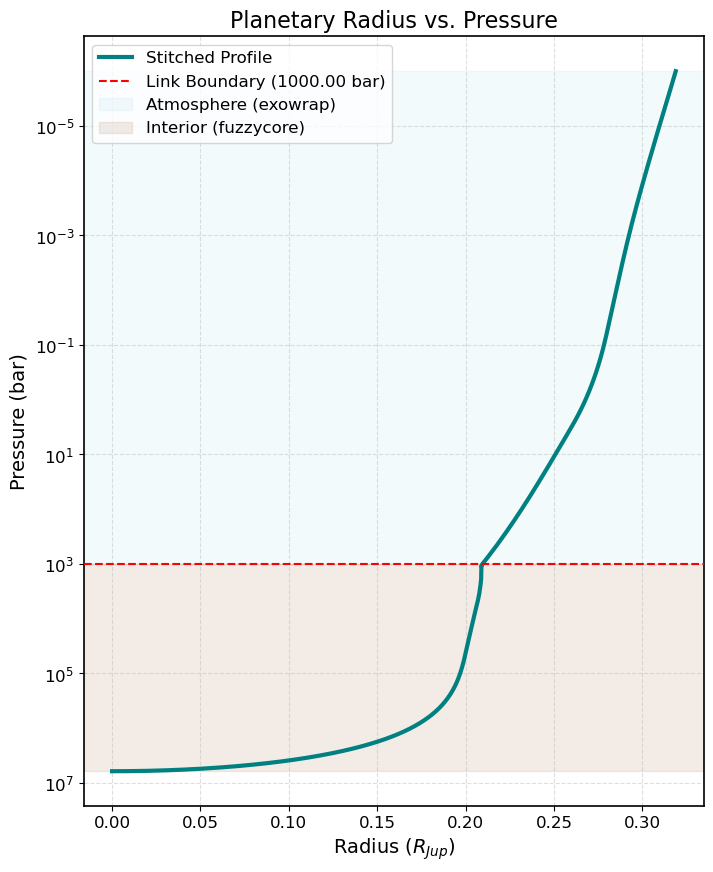

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure we have a converged result to plot
if results_sharp['status'] == 'converged':
    df = results_sharp['stitched_profile']
    p_link = results_sharp['final_params']['p_link_bar']
    
    # Handle column names dynamically (in case your master profile uses meters instead of Jupiter Radii)
    if 'Radius_Rjup' in df.columns:
        r_col = 'Radius_Rjup'
        x_label = "Radius ($R_{Jup}$)"
    elif 'Radius_m' in df.columns:
        # Convert meters to Jupiter radii on the fly (1 R_Jup = 71,492,000 m)
        df['Radius_Rjup_tmp'] = df['Radius_m'] / 71492000.0
        r_col = 'Radius_Rjup_tmp'
        x_label = "Radius ($R_{Jup}$)"
    else:
        # Fallback if standard names aren't found
        r_col = [col for col in df.columns if 'rad' in col.lower()][0]
        x_label = "Radius"
    
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # 1. Plot the continuous Radius vs. Pressure curve
    ax.plot(df[r_col], df['Pressure_bar'], color='teal', lw=3, zorder=3, label='Stitched Profile')
    
    # 2. Draw a line showing exactly where the two models linked
    ax.axhline(p_link, color='red', linestyle='--', zorder=4, label=f'Link Boundary ({p_link:.2f} bar)')
    
    # 3. Format the axes (Log pressure, inverted so the deep core is at the bottom)
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_xlabel(x_label, fontsize=14)
    ax.set_ylabel("Pressure (bar)", fontsize=14)
    ax.set_title("Planetary Radius vs. Pressure", fontsize=16)
    
    # 4. Fill background colors to show physical domains
    ax.axhspan(df['Pressure_bar'].min(), p_link, color='skyblue', alpha=0.1, label='Atmosphere (exowrap)')
    ax.axhspan(p_link, df['Pressure_bar'].max(), color='saddlebrown', alpha=0.1, label='Interior (fuzzycore)')
    
    # Add a grid for easier reading of specific depths
    plt.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(loc='upper left')
    
    plt.show()
else:
    print("The model did not converge. Please check the logs!")

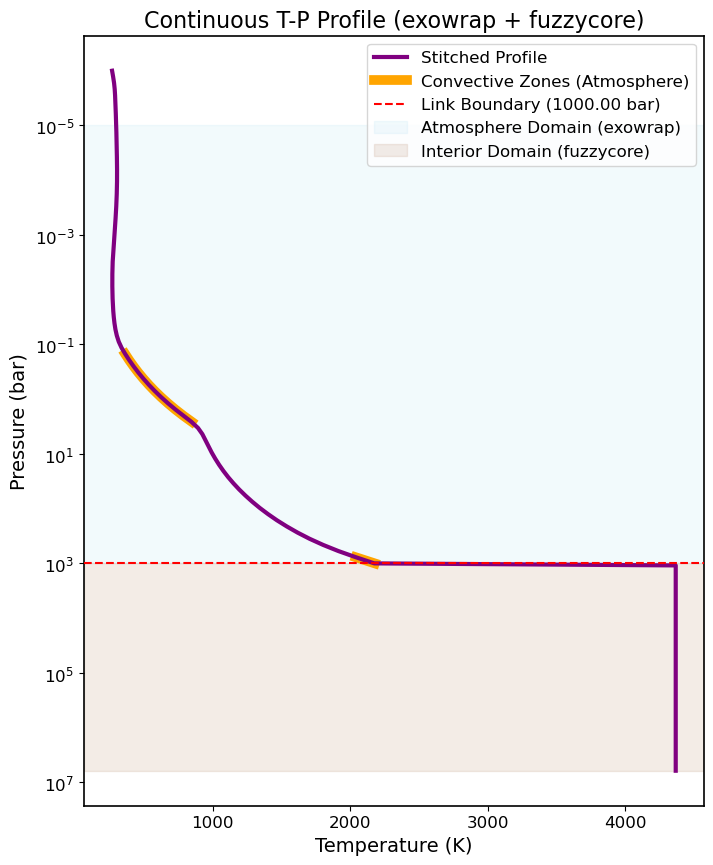

In [ ]:
# 6. Visualize the continuous planetary profile
if results_sharp['status'] == 'converged':
    df = results_sharp['stitched_profile']
    p_link = results_sharp['final_params']['p_link_bar']
    
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # 1. Plot the full stitched profile
    ax.plot(df['Temperature_K'], df['Pressure_bar'], color='purple', lw=3, zorder=3, label='Stitched Profile')
    
    # 2. Extract and overlay the convective zones from the atmosphere!
    atm_raw = results_sharp['atmosphere_raw']
    p_atm_bar = atm_raw['/outputs/levels/pressure'].iloc[0] / 1e5
    t_atm = atm_raw['/outputs/levels/temperature'].iloc[0]
    is_conv = atm_raw['/outputs/levels/is_convective'].iloc[0].astype(bool)
    
    # Replace all non-convective temperatures with NaN
    t_conv = np.where(is_conv, t_atm, np.nan)
    
    # Plot the bold overlay (Matplotlib automatically skips the NaNs!)
    ax.plot(t_conv, p_atm_bar, color='orange', lw=7, zorder=2, label='Convective Zones (Atmosphere)')
    
    # 3. Draw a line showing exactly where the two models linked
    ax.axhline(p_link, color='red', linestyle='--', zorder=4, label=f'Link Boundary ({p_link:.2f} bar)')
    
    # 4. Format the axes for atmospheric science standards (log pressure, inverted)
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_xlabel("Temperature (K)", fontsize=14)
    ax.set_ylabel("Pressure (bar)", fontsize=14)
    ax.set_title("Continuous T-P Profile (exowrap + fuzzycore)", fontsize=16)
    
    # 5. Fill background colors to show domains
    ax.axhspan(1e-5, p_link, color='skyblue', alpha=0.1, label='Atmosphere Domain (exowrap)')
    ax.axhspan(p_link, df['Pressure_bar'].max(), color='saddlebrown', alpha=0.1, label='Interior Domain (fuzzycore)')
    
    ax.legend(loc='upper right')
    plt.show()

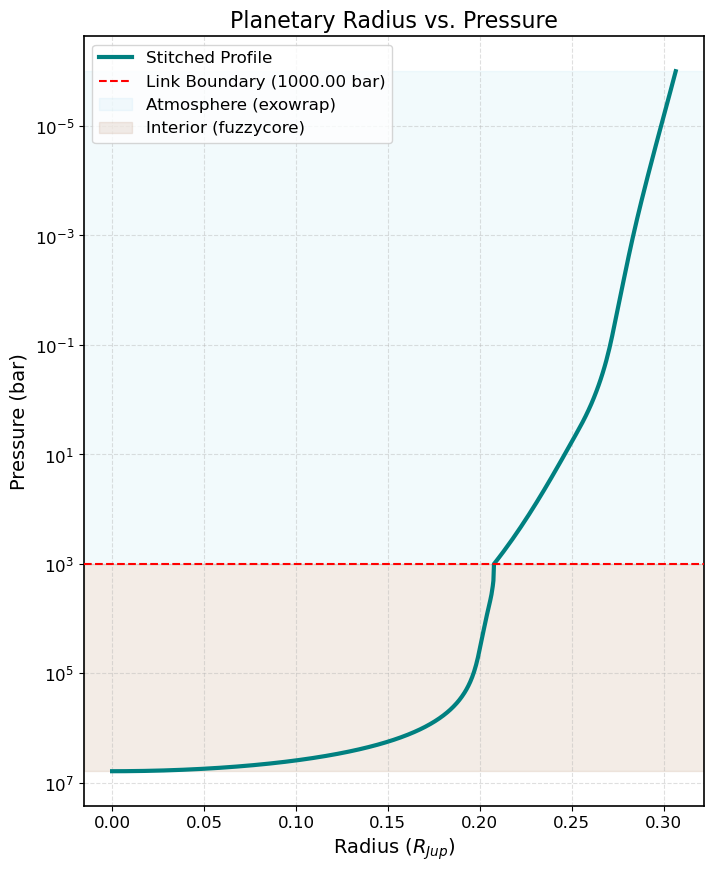

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure we have a converged result to plot
if results_fuzzy['status'] == 'converged':
    df = results_fuzzy['stitched_profile']
    p_link = results_fuzzy['final_params']['p_link_bar']
    
    # Handle column names dynamically (in case your master profile uses meters instead of Jupiter Radii)
    if 'Radius_Rjup' in df.columns:
        r_col = 'Radius_Rjup'
        x_label = "Radius ($R_{Jup}$)"
    elif 'Radius_m' in df.columns:
        # Convert meters to Jupiter radii on the fly (1 R_Jup = 71,492,000 m)
        df['Radius_Rjup_tmp'] = df['Radius_m'] / 71492000.0
        r_col = 'Radius_Rjup_tmp'
        x_label = "Radius ($R_{Jup}$)"
    else:
        # Fallback if standard names aren't found
        r_col = [col for col in df.columns if 'rad' in col.lower()][0]
        x_label = "Radius"
    
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # 1. Plot the continuous Radius vs. Pressure curve
    ax.plot(df[r_col], df['Pressure_bar'], color='teal', lw=3, zorder=3, label='Stitched Profile')
    
    # 2. Draw a line showing exactly where the two models linked
    ax.axhline(p_link, color='red', linestyle='--', zorder=4, label=f'Link Boundary ({p_link:.2f} bar)')
    
    # 3. Format the axes (Log pressure, inverted so the deep core is at the bottom)
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_xlabel(x_label, fontsize=14)
    ax.set_ylabel("Pressure (bar)", fontsize=14)
    ax.set_title("Planetary Radius vs. Pressure", fontsize=16)
    
    # 4. Fill background colors to show physical domains
    ax.axhspan(df['Pressure_bar'].min(), p_link, color='skyblue', alpha=0.1, label='Atmosphere (exowrap)')
    ax.axhspan(p_link, df['Pressure_bar'].max(), color='saddlebrown', alpha=0.1, label='Interior (fuzzycore)')
    
    # Add a grid for easier reading of specific depths
    plt.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(loc='upper left')
    
    plt.show()
else:
    print("The model did not converge. Please check the logs!")

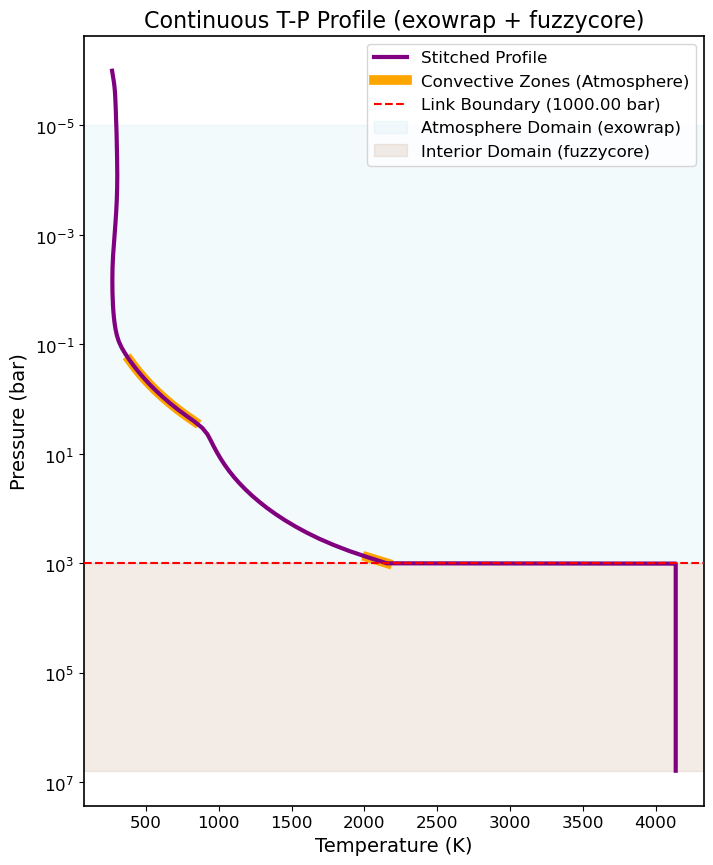

In [ ]:
# 6. Visualize the continuous planetary profile
if results_fuzzy['status'] == 'converged':
    df = results_fuzzy['stitched_profile']
    p_link = results_fuzzy['final_params']['p_link_bar']
    
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # 1. Plot the full stitched profile
    ax.plot(df['Temperature_K'], df['Pressure_bar'], color='purple', lw=3, zorder=3, label='Stitched Profile')
    
    # 2. Extract and overlay the convective zones from the atmosphere!
    atm_raw = results_fuzzy['atmosphere_raw']
    p_atm_bar = atm_raw['/outputs/levels/pressure'].iloc[0] / 1e5
    t_atm = atm_raw['/outputs/levels/temperature'].iloc[0]
    is_conv = atm_raw['/outputs/levels/is_convective'].iloc[0].astype(bool)
    
    # Replace all non-convective temperatures with NaN
    t_conv = np.where(is_conv, t_atm, np.nan)
    
    # Plot the bold overlay (Matplotlib automatically skips the NaNs!)
    ax.plot(t_conv, p_atm_bar, color='orange', lw=7, zorder=2, label='Convective Zones (Atmosphere)')
    
    # 3. Draw a line showing exactly where the two models linked
    ax.axhline(p_link, color='red', linestyle='--', zorder=4, label=f'Link Boundary ({p_link:.2f} bar)')
    
    # 4. Format the axes for atmospheric science standards (log pressure, inverted)
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_xlabel("Temperature (K)", fontsize=14)
    ax.set_ylabel("Pressure (bar)", fontsize=14)
    ax.set_title("Continuous T-P Profile (exowrap + fuzzycore)", fontsize=16)
    
    # 5. Fill background colors to show domains
    ax.axhspan(1e-5, p_link, color='skyblue', alpha=0.1, label='Atmosphere Domain (exowrap)')
    ax.axhspan(p_link, df['Pressure_bar'].max(), color='saddlebrown', alpha=0.1, label='Interior Domain (fuzzycore)')
    
    ax.legend(loc='upper right')
    plt.show()